In [ ]:
import sys, os
sys.path.append(os.path.abspath('..'))

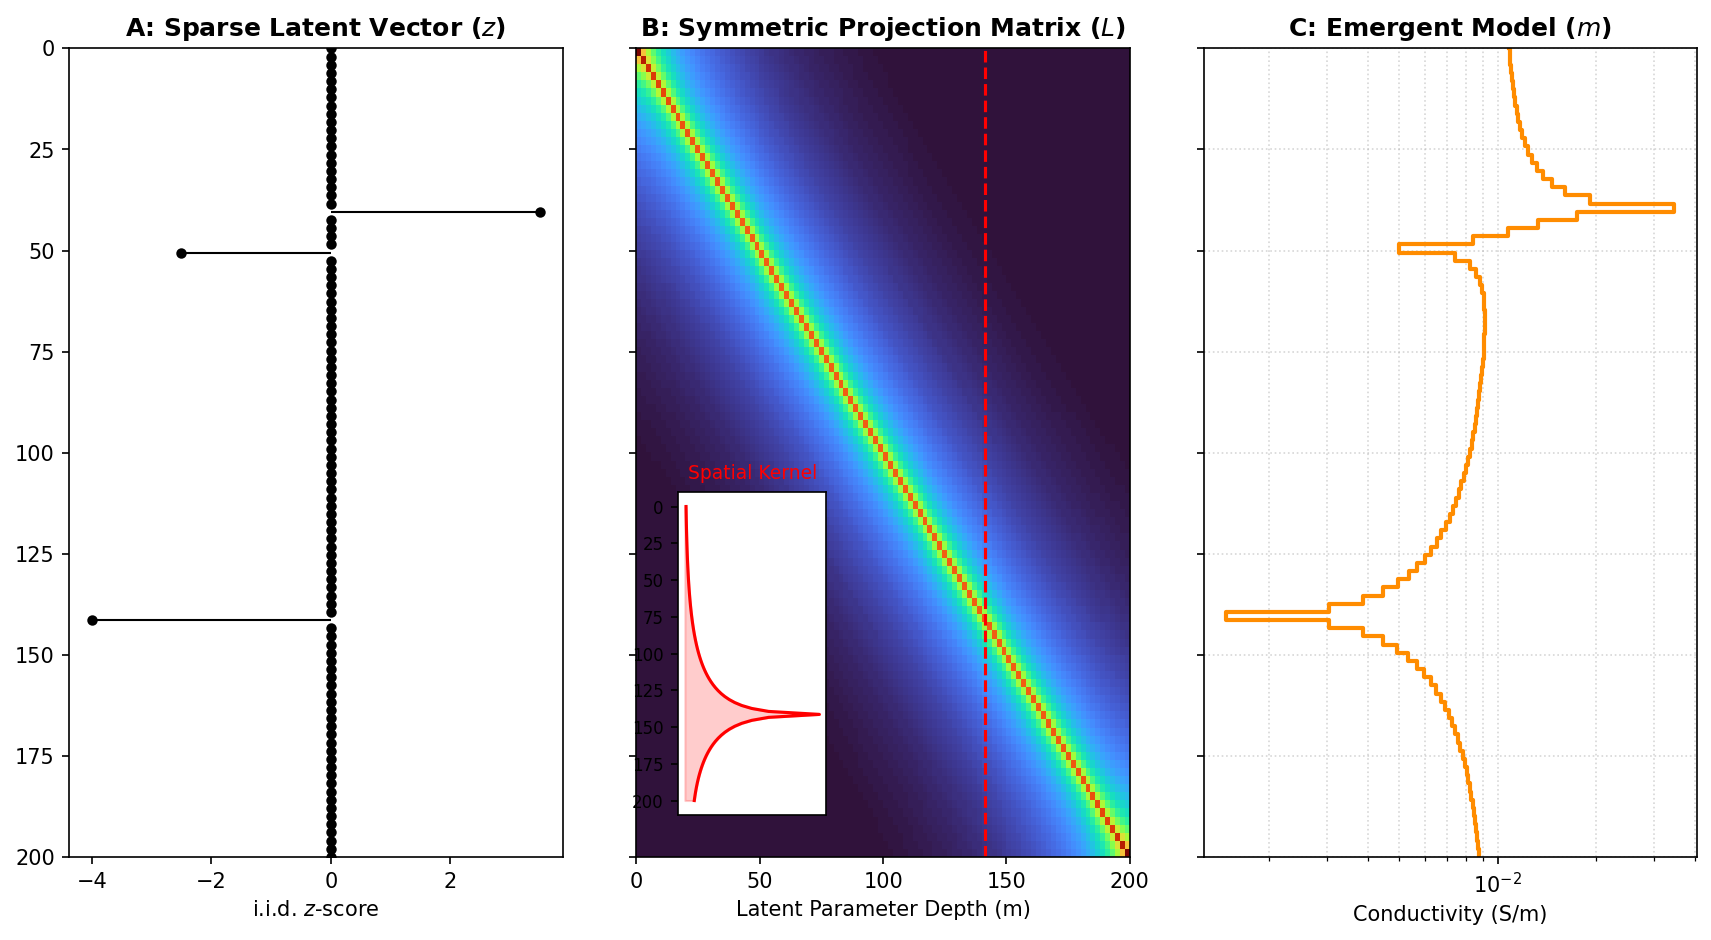

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- 1. Setup Environment (Same as before) ---
n_layers = 100
depths = np.linspace(0, 200, n_layers)
z = np.zeros(n_layers)
z[20], z[25], z[70] = 3.5, -2.5, -4.0 # Structural triggers

# --- 2. SVD Operator ---
dist = np.abs(depths[:, None] - depths[None, :])
corr_len = 50.0 
C = np.exp(-dist / corr_len) + np.eye(n_layers) * 1e-6
U, S, Vt = np.linalg.svd(C)
S_sqrt = np.diag(np.sqrt(np.clip(S, 1e-10, None)))
L_svd = U @ S_sqrt @ U.T

# --- 3. Physical Model ---
mu = np.log(0.01)
m_physical = np.exp(L_svd @ z + mu)

# --- 4. Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(14, 7), sharey=True, dpi=150)
plt.subplots_adjust(wspace=0.15)

# Panel A: Latent Vector
axes[0].hlines(depths, 0, z, color='black', lw=1)
axes[0].plot(z, depths, 'ko', ms=4)
axes[0].set_title('A: Sparse Latent Vector ($z$)', fontweight='bold')
axes[0].set_xlabel('i.i.d. $z$-score')
axes[0].invert_yaxis()

# Panel B: SVD Matrix + Inset Slice
im = axes[1].imshow(L_svd, extent=[0, 200, 200, 0], aspect='auto', cmap='turbo',vmax=0.6,vmin=0.01)
axes[1].set_title('B: Symmetric Projection Matrix ($L$)', fontweight='bold')
axes[1].set_xlabel('Latent Parameter Depth (m)')

# The Vertical Slice (Red Line)
trigger_depth_idx = 70
trigger_depth = depths[trigger_depth_idx]
axes[1].axvline(trigger_depth, color='red', ls='--', lw=1.5)

# --- INSET SUBPLOT ---
# Creating an inset to show the 1D weight distribution of that red line
ax_inset = inset_axes(axes[1], width="30%", height="40%", loc='lower left', borderpad=2)
kernel_slice = L_svd[:, trigger_depth_idx]
ax_inset.plot(kernel_slice, depths, color='red', lw=1.5)
ax_inset.fill_betweenx(depths, 0, kernel_slice, color='red', alpha=0.2)
ax_inset.set_title('Spatial Kernel', fontsize=9, color='red')
ax_inset.invert_yaxis()
ax_inset.set_xticks([]) # Keep it clean
ax_inset.tick_params(axis='y', labelsize=8)

# Panel C: Physical Model
axes[2].plot(m_physical, depths, color='darkorange', lw=2, drawstyle='steps-post')
axes[2].set_xscale('log')
axes[2].set_title('C: Emergent Model ($m$)', fontweight='bold')
axes[2].set_xlabel('Conductivity (S/m)')
axes[2].grid(True, which='both', ls=':', alpha=0.5)

plt.savefig('vector_transform.png',dpi=200)